# K-NN实现红酒分类

## 1、加载、查看红酒数据集



In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.datasets import load_wine # 导入红酒数据集
from sklearn.model_selection import train_test_split # 拆分数据集模块
from sklearn.neighbors import KNeighborsClassifier # KNN模块
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 加载wine数据集
wine = load_wine()
print(wine.keys()) # 查看数据集构成

print('shape of data:', wine.data.shape) # 查看样本数据的形状
print('shape of target:', wine.target.shape) # 查看标签数据的形状
print('target_names:', wine.target_names) # 查看红酒类别名称
print('feature_names:', wine.feature_names) # 样本的十三个特征名称


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])
shape of data: (178, 13)
shape of target: (178,)
target_names: ['class_0' 'class_1' 'class_2']
feature_names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [3]:
# 使用pandas查看样本数据
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


## 2、数据集可视化

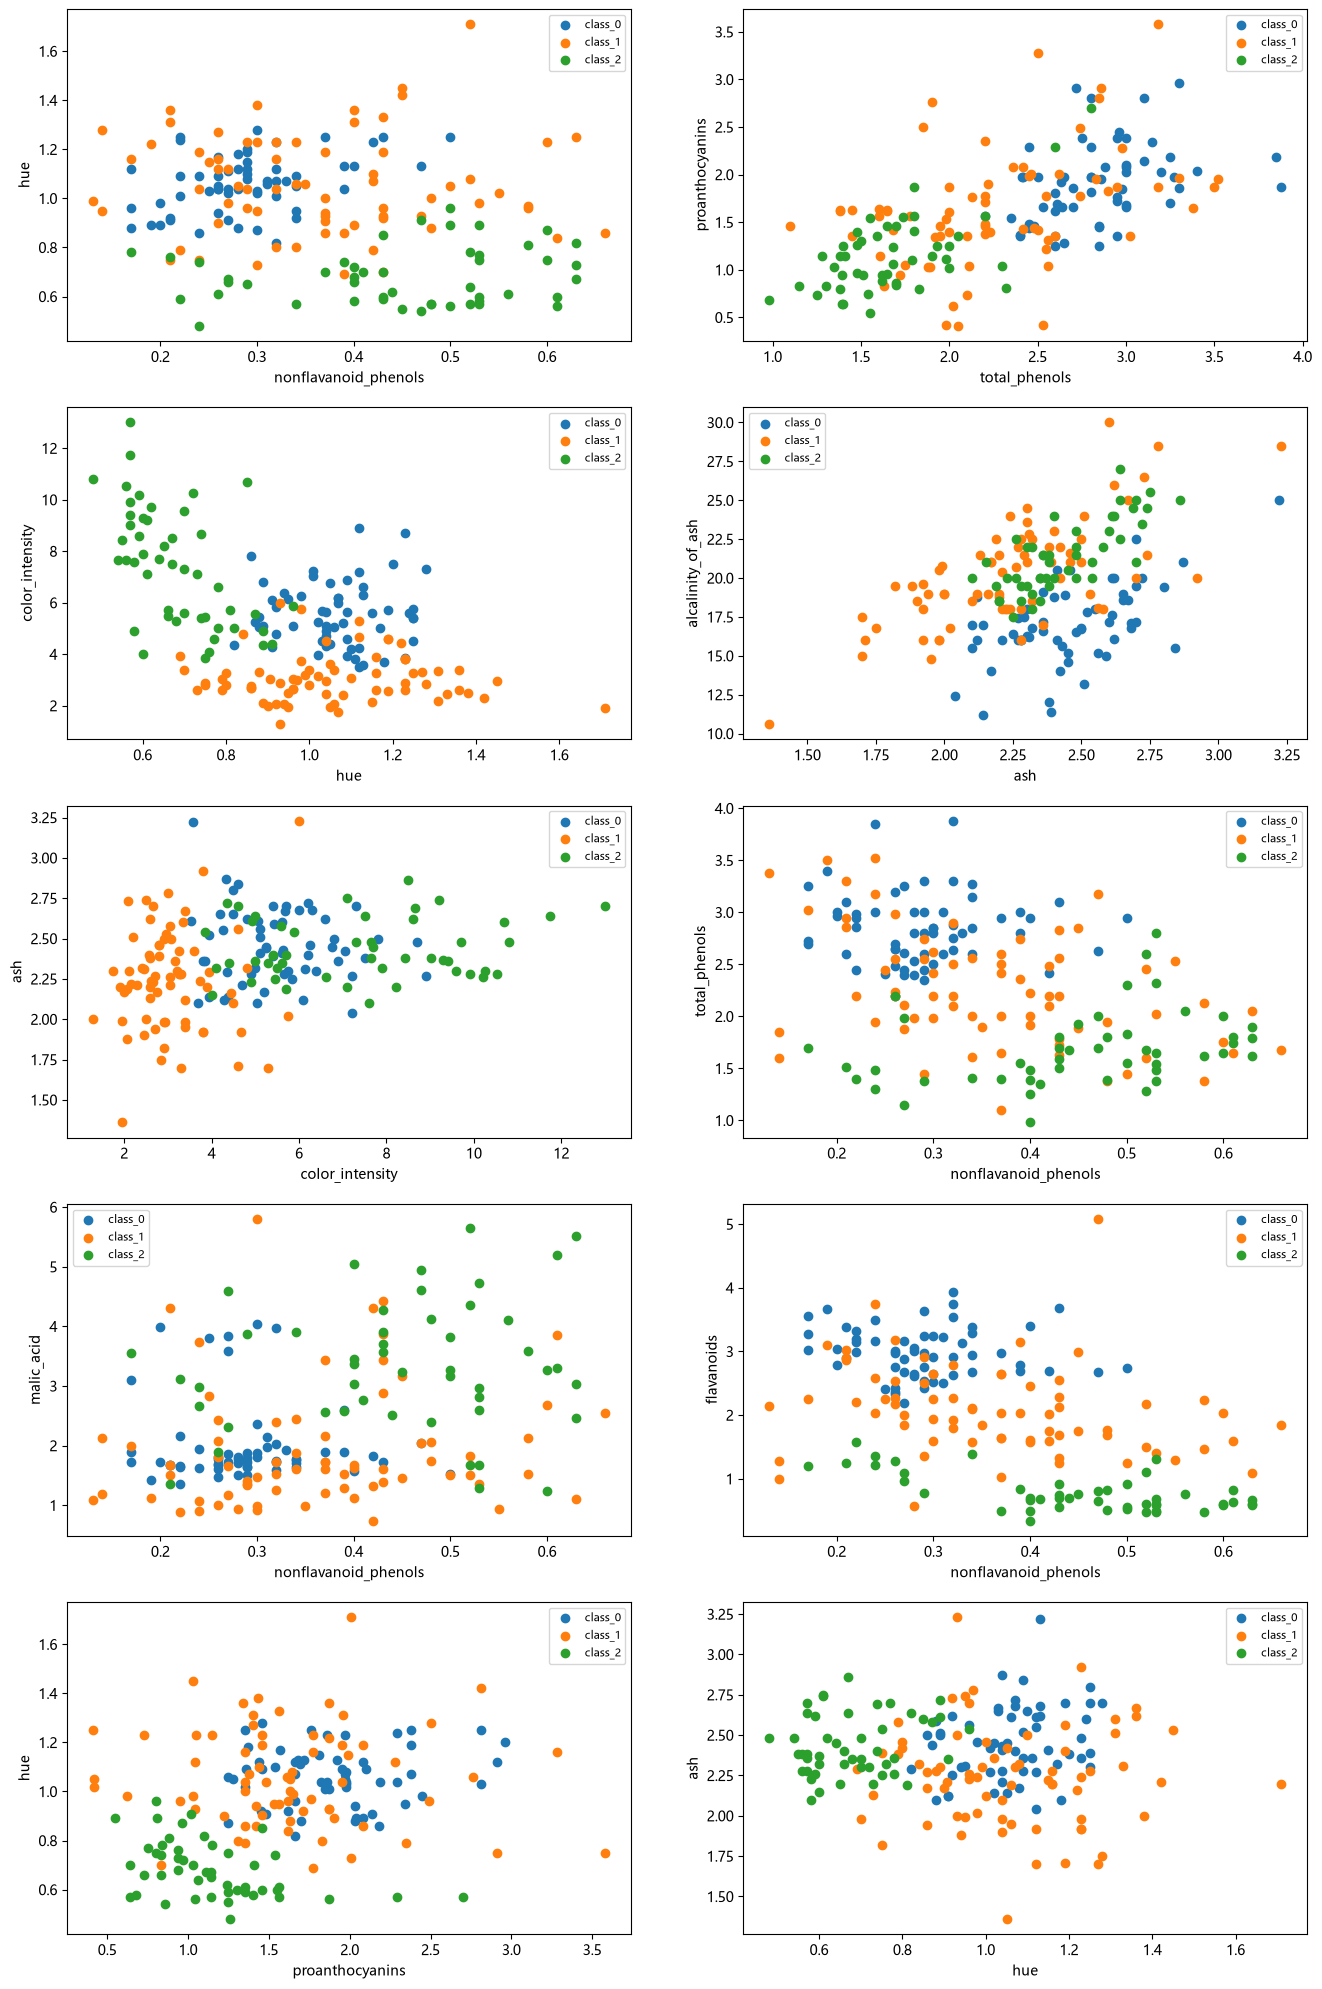

In [4]:
import random

# wine数据集可视化
fig = plt.figure(figsize=(16,25)) # 定义画板尺寸(16,25)

data = wine.data # 样本数据
target = wine.target # 数据标签
target_names = wine.target_names  # 标签名称
feature_names = wine.feature_names # 特征名称

# 任选2个特征生成散点图，共生成10个子图
for i in range(10):
    random_feature = random.sample(range(13), 2) # 任选2个特征
    ax = fig.add_subplot(5, 2, i+1) # 添加子图（5行2列，第i+1个子图）
    for j in range(3): # 依次显示每个种类（共3类）的数据
        ax.scatter(data[target==j, random_feature[0]],
                   data[target==j, random_feature[1]], label=target_names[j])
    ax.set_xlabel(feature_names[random_feature[0]])
    ax.set_ylabel(feature_names[random_feature[1]])
    ax.legend(fontsize=8)


## 3、将数据集拆分为训练集和测试集

In [5]:
# 拆分数据集
# test_size=0.25(25%作为测试集，75%作为训练集)
# random_state=0(随机数种子，固定随机结果，便于数据重现)
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target,
                                                    test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape)


(133, 13) (45, 13)


## 4、构建K-NN分类模型

In [6]:
# 构建模型
model = KNeighborsClassifier()
model.fit(X_train, y_train) # 拟合训练数据

# 评估模型
score = model.score(X_test, y_test)
print('Score:{:.2f}'.format(score))

# 预测红酒种类
y_pred = model.predict(X_test[:5]) # 预测测试集前五个样本的品种
print(y_pred) # 打印预测结果
print(y_test[:5]) # 打印实际品种


Score:0.73
[0 1 1 0 1]
[0 2 1 0 1]
